In [1]:
catalogo = [
    ("Toyota Hilux 2024", "camioneta pickup con motor turbodiesel, traccion 4x4, ideal para trabajo pesado y offroad"),
    ("Ford Ranger 2024", "pickup mediana con motor turbo y chasis reforzado, disenada para terrenos dificiles"),
    ("Nissan Leaf 2024", "hatchback 100% electrico, silencioso y eficiente, pensado para uso urbano diario"),
    ("Chevrolet Bolt EV 2024", "auto electrico compacto, carga rapida, bajo costo de mantenimiento, ideal para la ciudad"),
    ("BMW X5 2024", "suv premium con interior de cuero, tecnologia avanzada y motor de alto rendimiento"),
    ("Mercedes-Benz GLE 2024", "suv de lujo con suspension adaptativa y acabados premium"),
    ("Jeep Wrangler 2024", "todoterreno 4x4 con carroceria removible, disenado para exploracion extrema en montana y rios"),
    ("Land Rover Defender 2024", "todoterreno robusto con vadeo profundo, construido para climas humedos y terrenos extremos"),
]

In [2]:
pares = []
for i, (title_i, body_i) in enumerate(catalogo):
    pares.append((title_i, body_i, 1))
    for j, (title_j, body_j) in enumerate(catalogo):
        if i != j:
            pares.append((title_i, body_j, 0))

print(f"Total de pares: {len(pares)}")
print(pares[0])

Total de pares: 64
('Toyota Hilux 2024', 'camioneta pickup con motor turbodiesel, traccion 4x4, ideal para trabajo pesado y offroad', 1)


In [3]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

textos_entrenamiento = [texto_a + " " + texto_b for texto_a, texto_b, _ in pares]

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    special_tokens=["[UNK]"],
    vocab_size=500,
    min_frequency=2,
)

tokenizer.train_from_iterator(textos_entrenamiento, trainer)

print("Vocabulario final:", tokenizer.get_vocab_size())

Vocabulario final: 357


In [4]:
for palabra in ["camioneta", "motor", "electrico", "premium", "wayrapiquero", "wayrasacha"]:
    output = tokenizer.encode(palabra)
    print(f"{palabra:14} -> {output.tokens}")

camioneta      -> ['camioneta']
motor          -> ['motor']
electrico      -> ['electrico']
premium        -> ['premium']
wayrapiquero   -> ['[UNK]', 'a', 'y', 'ra', 'p', 'i', '[UNK]', 'u', 'ero']
wayrasacha     -> ['[UNK]', 'a', 'y', 'ra', 's', 'a', 'ch', 'a']


In [5]:
import torch
import torch.nn as nn

# ---- Definir las piezas (pesos), sueltas, no dentro de una clase ----
d, d_ff = 16, 32

Wq = nn.Linear(d, d, bias=False)
Wk = nn.Linear(d, d, bias=False)
Wv = nn.Linear(d, d, bias=False)

In [6]:
print(Wq.weight.shape) 

torch.Size([16, 16])


In [7]:
norm1 = nn.LayerNorm(d)
norm1


LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)

In [8]:
print(norm1.weight.shape) 

torch.Size([16])


In [9]:
print(norm1.weight.shape)

torch.Size([16])


In [10]:
print(norm1.bias.shape) 

torch.Size([16])


In [11]:
ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))

In [12]:
ff

Sequential(
  (0): Linear(in_features=16, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
)

In [13]:
norm2 = nn.LayerNorm(d)
print(norm1.weight.shape)

torch.Size([16])


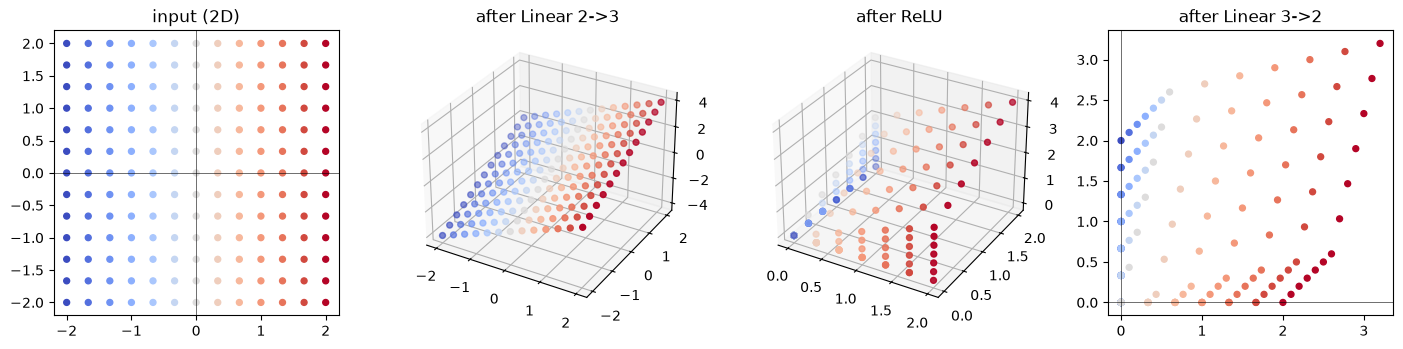

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

lin1 = nn.Linear(2, 3, bias=False)
relu = nn.ReLU()
lin2 = nn.Linear(3, 2, bias=False)

lin1.weight.data = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])
lin2.weight.data = torch.tensor([
    [1.0, 0.0, 0.3],
    [0.0, 1.0, 0.3],
])

xs = torch.linspace(-2, 2, 13)
ys = torch.linspace(-2, 2, 13)
xx, yy = torch.meshgrid(xs, ys, indexing="ij")
pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
color = pts[:, 0]

h = lin1(pts).detach()
h_relu = relu(h).detach()
out = lin2(h_relu).detach()

fig = plt.figure(figsize=(14, 4))

ax = fig.add_subplot(1, 4, 1)
ax.scatter(pts[:, 0], pts[:, 1], c=color, cmap="coolwarm", s=18)
ax.set_title("input (2D)")
ax.set_aspect("equal")
ax.axhline(0, color="k", lw=0.4)
ax.axvline(0, color="k", lw=0.4)

ax = fig.add_subplot(1, 4, 2, projection="3d")
ax.scatter(h[:, 0], h[:, 1], h[:, 2], c=color, cmap="coolwarm", s=18)
ax.set_title("after Linear 2->3")

ax = fig.add_subplot(1, 4, 3, projection="3d")
ax.scatter(h_relu[:, 0], h_relu[:, 1], h_relu[:, 2], c=color, cmap="coolwarm", s=18)
ax.set_title("after ReLU")

ax = fig.add_subplot(1, 4, 4)
ax.scatter(out[:, 0], out[:, 1], c=color, cmap="coolwarm", s=18)
ax.set_title("after Linear 3->2")
ax.set_aspect("equal")
ax.axhline(0, color="k", lw=0.4)
ax.axvline(0, color="k", lw=0.4)

plt.tight_layout()
plt.show()

premium   in=[1.0, 0.800000011920929]  lin1=[1.0, 0.800000011920929, 1.7999999523162842]  relu=[1.0, 0.800000011920929, 1.7999999523162842]  lin2=[1.5399999618530273, 1.340000033378601]
caro      in=[0.8999999761581421, 0.699999988079071]  lin1=[0.8999999761581421, 0.699999988079071, 1.5999999046325684]  relu=[0.8999999761581421, 0.699999988079071, 1.5999999046325684]  lin2=[1.3799999952316284, 1.1799999475479126]
barato    in=[-1.0, -0.6000000238418579]  lin1=[-1.0, -0.6000000238418579, -1.600000023841858]  relu=[0.0, 0.0, 0.0]  lin2=[0.0, 0.0]


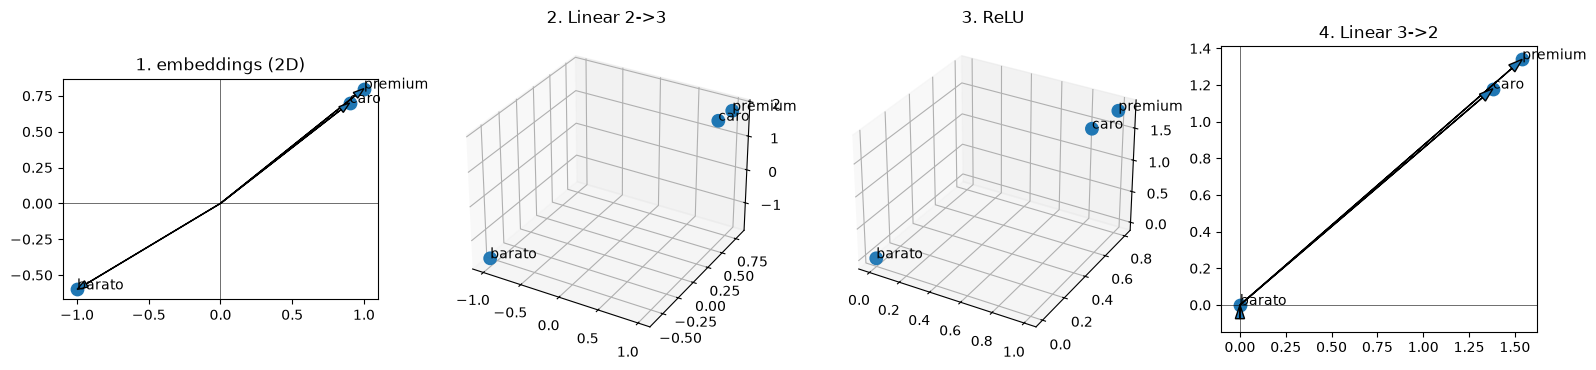

In [15]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

palabras = ["premium", "caro", "barato"]
E = torch.tensor([
    [ 1.0,  0.8],   # premium
    [ 0.9,  0.7],   # caro
    [-1.0, -0.6],   # barato
])

lin1 = nn.Linear(2, 3, bias=False)
relu = nn.ReLU()
lin2 = nn.Linear(3, 2, bias=False)

# (x, y) -> (x, y, x+y)
lin1.weight.data = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])
# (x, y, z) -> (x + 0.3z, y + 0.3z)
lin2.weight.data = torch.tensor([
    [1.0, 0.0, 0.3],
    [0.0, 1.0, 0.3],
])

h = lin1(E).detach()
h_relu = relu(h).detach()
out = lin2(h_relu).detach()

for i, w in enumerate(palabras):
    print(f"{w:8}  in={E[i].tolist()}  lin1={h[i].tolist()}  relu={h_relu[i].tolist()}  lin2={out[i].tolist()}")

fig = plt.figure(figsize=(16, 4))

ax = fig.add_subplot(1, 4, 1)
ax.scatter(E[:, 0], E[:, 1], s=80)
for w, v in zip(palabras, E):
    ax.annotate(w, (float(v[0]), float(v[1])))
    ax.arrow(0, 0, float(v[0]), float(v[1]), head_width=0.05, length_includes_head=True)
ax.set_title("1. embeddings (2D)")
ax.set_aspect("equal")
ax.axhline(0, color="k", lw=0.4)
ax.axvline(0, color="k", lw=0.4)

ax = fig.add_subplot(1, 4, 2, projection="3d")
ax.scatter(h[:, 0], h[:, 1], h[:, 2], s=80)
for w, v in zip(palabras, h):
    ax.text(float(v[0]), float(v[1]), float(v[2]), w)
ax.set_title("2. Linear 2->3")

ax = fig.add_subplot(1, 4, 3, projection="3d")
ax.scatter(h_relu[:, 0], h_relu[:, 1], h_relu[:, 2], s=80)
for w, v in zip(palabras, h_relu):
    ax.text(float(v[0]), float(v[1]), float(v[2]), w)
ax.set_title("3. ReLU")

ax = fig.add_subplot(1, 4, 4)
ax.scatter(out[:, 0], out[:, 1], s=80)
for w, v in zip(palabras, out):
    ax.annotate(w, (float(v[0]), float(v[1])))
    ax.arrow(0, 0, float(v[0]), float(v[1]), head_width=0.05, length_includes_head=True)
ax.set_title("4. Linear 3->2")
ax.set_aspect("equal")
ax.axhline(0, color="k", lw=0.4)
ax.axvline(0, color="k", lw=0.4)

plt.tight_layout()
plt.show()

cosine BEFORE  premium-caro 0.9958931803703308   premium-barato 0.9998000264167786
cosine AFTER   premium-caro 0.9992940425872803   premium-barato 0.5144956707954407
premium   in=[0.6000000238418579, 0.5]  lin1=[0.6000000238418579, 0.20000004768371582]  relu=[0.6000000238418579, 0.20000004768371582]  out=[0.6000000238418579, 1.000000238418579]
caro      in=[0.550000011920929, 0.550000011920929]  lin1=[0.550000011920929, 0.20000004768371582]  relu=[0.550000011920929, 0.20000004768371582]  out=[0.550000011920929, 1.000000238418579]
barato    in=[0.5, 0.4000000059604645]  lin1=[0.5, -0.20000004768371582]  relu=[0.5, 0.0]  out=[0.5, 0.0]


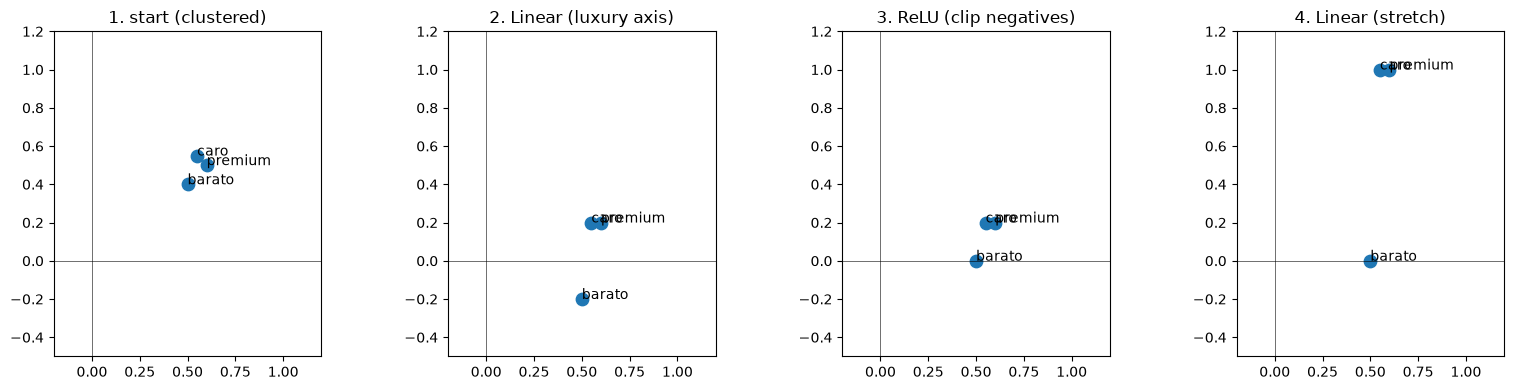

In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

palabras = ["premium", "caro", "barato"]
E = torch.tensor([
    [0.60, 0.50],  # premium
    [0.55, 0.55],  # caro     almost the same point
    [0.50, 0.40],  # barato   also in the same blob
])

lin1 = nn.Linear(2, 2)
relu = nn.ReLU()
lin2 = nn.Linear(2, 2, bias=False)

# Linear 1: keep x, and score = 2x + 2y - 2  (a "luxury" axis)
lin1.weight.data = torch.tensor([
    [1.0, 0.0],
    [2.0, 2.0],
])
lin1.bias.data = torch.tensor([0.0, -2.0])

# Linear 2: stretch that score x5
lin2.weight.data = torch.tensor([
    [1.0, 0.0],
    [0.0, 5.0],
])

h = lin1(E).detach()
h_relu = relu(h).detach()
out = lin2(h_relu).detach()

def cos(a, b):
    return float(torch.dot(a, b) / (a.norm() * b.norm()))

print("cosine BEFORE  premium-caro", cos(E[0], E[1]), "  premium-barato", cos(E[0], E[2]))
print("cosine AFTER   premium-caro", cos(out[0], out[1]), "  premium-barato", cos(out[0], out[2]))
for i, w in enumerate(palabras):
    print(f"{w:8}  in={E[i].tolist()}  lin1={h[i].tolist()}  relu={h_relu[i].tolist()}  out={out[i].tolist()}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
stages = [
    (E, "1. start (clustered)"),
    (h, "2. Linear (luxury axis)"),
    (h_relu, "3. ReLU (clip negatives)"),
    (out, "4. Linear (stretch)"),
]
for ax, (pts, title) in zip(axes, stages):
    ax.scatter(pts[:, 0], pts[:, 1], s=80)
    for w, v in zip(palabras, pts):
        ax.annotate(w, (float(v[0]), float(v[1])))
    ax.axhline(0, color="k", lw=0.4)
    ax.axvline(0, color="k", lw=0.4)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.5, 1.2)
plt.tight_layout()
plt.show()

In [17]:
vocab_size = tokenizer.get_vocab_size()
max_len = 30

token_embed = nn.Embedding(vocab_size, d)
pos_embed = nn.Embedding(max_len, d)


In [18]:
tokenizer.get_vocab()

{'su': 85,
 'pro': 222,
 'os': 58,
 'x': 46,
 'acabados': 353,
 'e': 29,
 'mon': 212,
 'pickup': 136,
 'fu': 192,
 'terreno': 125,
 '4x4': 130,
 'humedos': 322,
 'adapta': 278,
 'urbano': 277,
 'si': 84,
 'N': 19,
 '0': 4,
 'cuero': 319,
 'G': 14,
 'bad': 167,
 'terren': 77,
 'on': 51,
 'ndo': 217,
 'compacto': 355,
 'suspen': 276,
 'ima': 205,
 'Hi': 149,
 'rapida': 247,
 'oneta': 245,
 'efici': 281,
 'ci': 64,
 'tr': 87,
 'alto': 271,
 'To': 157,
 'hat': 200,
 'Bolt': 298,
 'silen': 275,
 'ide': 100,
 'extrema': 294,
 'rocer': 266,
 'ter': 71,
 'anzada': 249,
 'ten': 231,
 'g': 31,
 'au': 162,
 'turbodies': 296,
 'pesado': 331,
 'todoterreno': 138,
 'Mercedes': 350,
 'avanzada': 315,
 'us': 115,
 'mo': 75,
 'dies': 253,
 'mi': 68,
 'av': 163,
 's': 42,
 'yota': 239,
 'ccion': 179,
 'con': 60,
 'ck': 171,
 'Nissan': 351,
 'ari': 166,
 'diario': 335,
 'tiv': 233,
 'BM': 141,
 'constr': 251,
 'bajo': 127,
 'n': 38,
 'p': 40,
 'extre': 128,
 'Chevrolet': 349,
 'jo': 81,
 'ch': 94,
 'R': 

In [19]:
vocab_size

357

In [20]:
token_embed

Embedding(357, 16)

In [21]:
pos_embed

Embedding(30, 16)

In [22]:
texto = catalogo[0][1]  # "camioneta pickup con motor turbodiesel..."
ids = torch.tensor(tokenizer.encode(texto).ids)
positions = torch.arange(len(ids))

print("ids:", ids)
print("positions:", positions)

ids: tensor([270, 136,  60,  92, 348,   2, 288, 130,   2, 133,  66, 287, 331,  47,
        329])
positions: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])


In [23]:
texto = catalogo[0][1]
ids = torch.tensor(tokenizer.encode(texto).ids)
positions = torch.arange(len(ids))

In [24]:
x = token_embed(ids) + pos_embed(positions)      # 1. entrada: token + posicion
x

tensor([[ 2.4468e+00,  3.4736e+00,  1.2922e+00,  2.3832e-01, -1.7364e+00,
         -1.4276e+00,  8.6852e-01, -4.3395e-01,  4.6588e-01,  2.4615e+00,
          1.0523e+00,  2.0798e+00, -6.5169e-01,  8.8556e-01,  1.0878e+00,
          7.6856e-01],
        [-5.3438e-01,  1.3200e+00,  4.8897e-01, -7.0480e-01, -3.5909e+00,
         -1.8984e+00,  9.9813e-01,  8.4687e-01,  1.0388e+00, -1.2541e+00,
          2.3248e+00,  1.2262e+00,  1.2131e+00,  7.2595e-01, -2.1875e-01,
          1.8374e+00],
        [ 3.7431e-01, -2.0241e+00, -2.4439e-01, -1.6189e+00,  1.1529e-01,
         -2.1585e+00,  1.0598e+00, -8.8518e-01, -1.2522e+00,  1.8937e+00,
          1.5596e+00, -9.9519e-04, -1.1667e+00,  1.9103e+00,  3.8219e-01,
          7.4239e-01],
        [-1.6061e+00,  1.1884e+00,  8.7855e-01,  1.3908e+00,  1.0104e+00,
          2.3160e+00,  1.3002e+00, -1.0352e+00,  7.7298e-01, -9.9682e-01,
          1.5387e-01, -3.4310e-01, -2.7654e+00,  4.2845e-01, -6.1769e-01,
          1.1398e+00],
        [-1.7752e-01

In [25]:
Q, K, V = Wq(x), Wk(x), Wv(x)                     # 2-4. proyecciones
Q

tensor([[ 0.1823,  0.0689,  0.7571, -0.6316, -1.9808, -1.1619, -0.1496, -0.3011,
         -1.4836,  0.1316, -1.0698,  0.1013, -0.6807, -0.7809, -1.4559,  0.5779],
        [ 0.2320, -0.2910,  0.8915, -0.4536,  0.1575, -0.6671, -0.9152, -1.0782,
         -0.8495,  0.0643,  0.2661, -2.1296, -0.5203, -0.1226, -0.4349, -0.2886],
        [ 0.0784,  0.3182,  0.2400,  0.9566, -0.9036, -1.0064, -0.3360,  0.5323,
         -0.4083,  1.7159,  0.3674, -0.4228,  0.1996,  1.3602, -0.1797, -0.5628],
        [ 0.7295,  1.5998, -1.4418, -0.3351,  1.4182,  0.4201,  0.9316, -0.2321,
          0.6702, -1.1951, -0.4045, -1.6737,  0.7573, -0.0967,  1.1991,  0.1452],
        [ 0.7023, -0.9747, -0.0914, -1.0194,  0.9668, -0.1894, -0.6976,  0.1641,
         -0.1226, -1.4631, -0.1222, -1.0631, -0.3198, -0.4567,  0.0038, -1.3888],
        [-0.1256,  0.3130,  0.1427,  0.2004, -0.6297,  0.2711,  0.2941, -0.0809,
         -0.1751, -0.1910,  0.0809,  0.3879, -0.4661,  0.0973, -0.1043,  0.0366],
        [-0.2190, -0.1

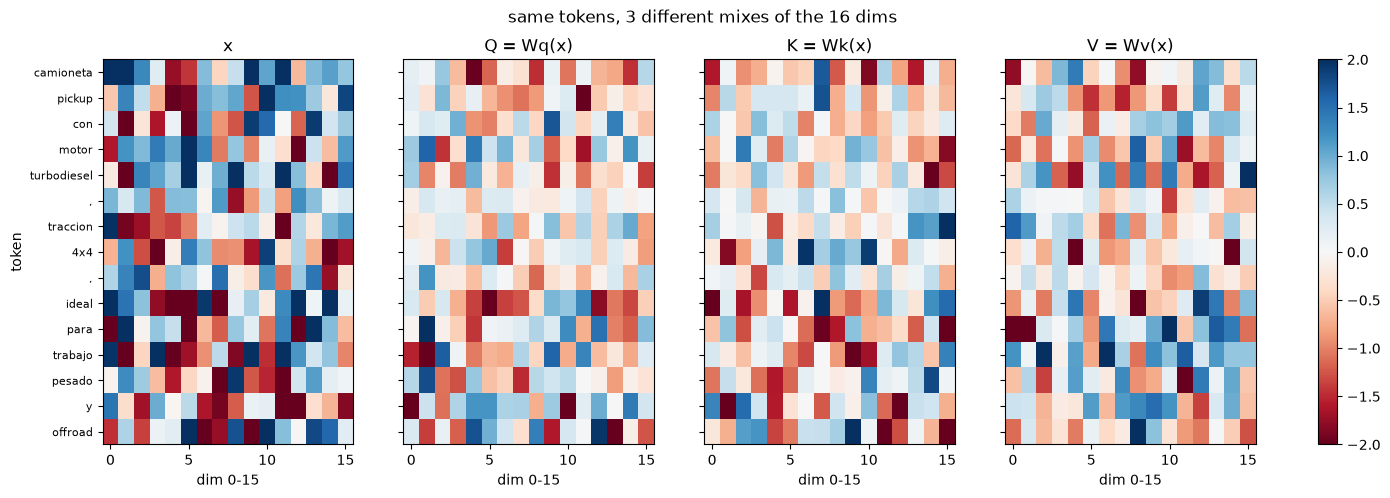

In [26]:
import matplotlib.pyplot as plt

tokens = tokenizer.encode(texto).tokens

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, mat, title in zip(axes, [x, Q, K, V], ["x", "Q = Wq(x)", "K = Wk(x)", "V = Wv(x)"]):
    im = ax.imshow(mat.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("dim 0-15")
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
axes[0].set_ylabel("token")
fig.colorbar(im, ax=axes, fraction=0.02)
plt.suptitle("same tokens, 3 different mixes of the 16 dims")
plt.show()

In [27]:
scores = Q @ K.transpose(-2, -1) / (d ** 0.5)     # 5. scores

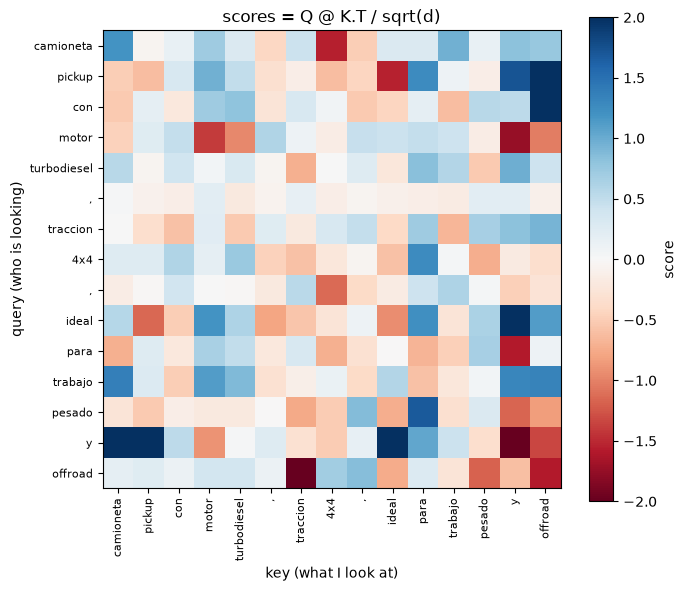

In [28]:
import matplotlib.pyplot as plt

tokens = tokenizer.encode(texto).tokens

plt.figure(figsize=(7, 6))
plt.imshow(scores.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2)
plt.colorbar(label="score")
plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
plt.yticks(range(len(tokens)), tokens, fontsize=8)
plt.xlabel("key (what I look at)")
plt.ylabel("query (who is looking)")
plt.title("scores = Q @ K.T / sqrt(d)")
plt.tight_layout()
plt.show()

In [29]:
weights = torch.softmax(scores, dim=-1)           # 6. softmax

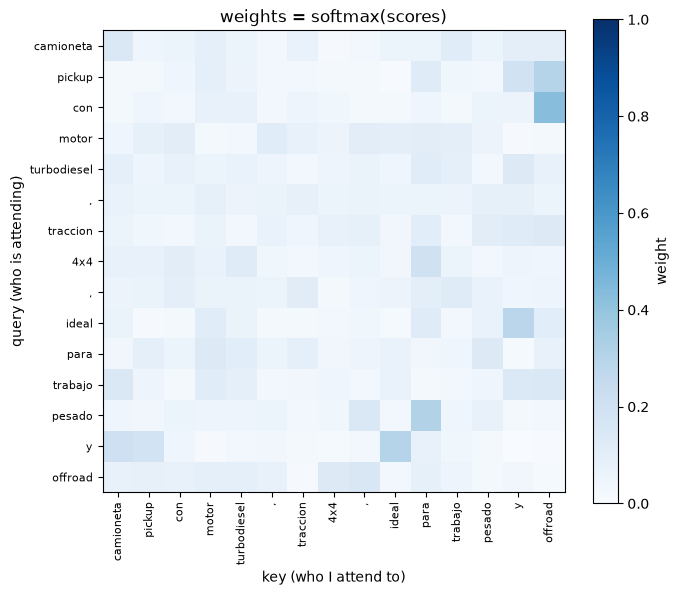

[0.9999999  1.0000001  1.         1.         1.0000002  0.99999994
 0.99999994 1.         1.         0.99999994 1.0000001  1.0000001
 1.         0.9999999  0.9999999 ]


In [30]:
import matplotlib.pyplot as plt

tokens = tokenizer.encode(texto).tokens

plt.figure(figsize=(7, 6))
plt.imshow(weights.detach().numpy(), cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="weight")
plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
plt.yticks(range(len(tokens)), tokens, fontsize=8)
plt.xlabel("key (who I attend to)")
plt.ylabel("query (who is attending)")
plt.title("weights = softmax(scores)")
plt.tight_layout()
plt.show()

print(weights.sum(dim=-1).detach().numpy())  # ~1.0 per row

In [31]:
attn_out = weights @ V                            # 7. mezcla ponderada

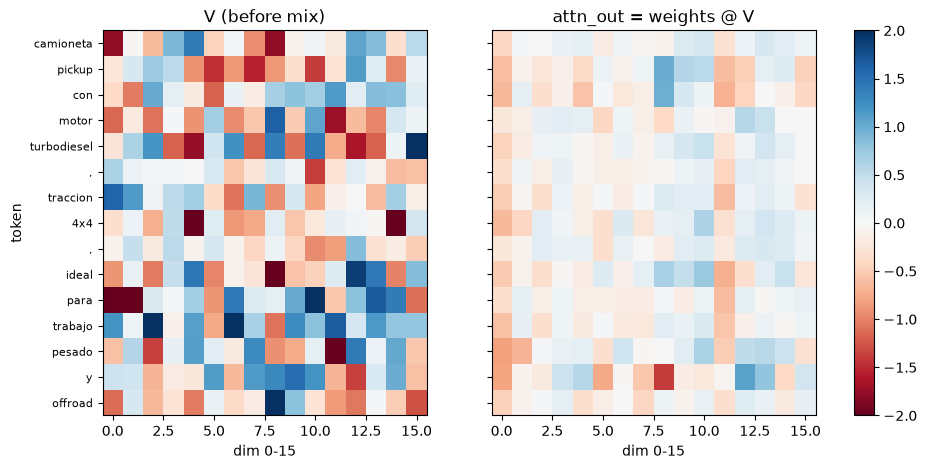

In [32]:
import matplotlib.pyplot as plt

tokens = tokenizer.encode(texto).tokens

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for ax, mat, title in zip(axes, [V, attn_out], ["V (before mix)", "attn_out = weights @ V"]):
    im = ax.imshow(mat.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("dim 0-15")
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
axes[0].set_ylabel("token")
fig.colorbar(im, ax=axes, fraction=0.03)
plt.show()

In [33]:
i = 0  # first token
print(tokens[i], "looks at:")
for w, t in zip(weights[i].detach(), tokens):
    print(f"  {t:16} {float(w):.3f}")

print("V mix:", (weights[i] @ V).detach().numpy())
print("attn_out[i]:", attn_out[i].detach().numpy())  # same numbers

camioneta looks at:
  camioneta        0.146
  pickup           0.042
  con              0.051
  motor            0.090
  turbodiesel      0.059
  ,                0.029
  traccion         0.068
  4x4              0.009
  ,                0.027
  ideal            0.059
  para             0.059
  trabajo          0.114
  pesado           0.051
  y                0.101
  offroad          0.094
V mix: [-0.4195083   0.03220253 -0.00605622  0.1337983   0.17858073 -0.16498728
  0.07600687 -0.04813541 -0.09068632  0.2742602   0.34994766 -0.30139413
  0.12149529  0.32115015  0.21515995  0.08239861]
attn_out[i]: [-0.41950837  0.03220255 -0.00605621  0.13379833  0.17858076 -0.16498724
  0.07600689 -0.04813544 -0.09068629  0.27426016  0.34994766 -0.3013941
  0.1214953   0.32115015  0.21515994  0.0823986 ]


In [34]:
x = norm1(x + attn_out)      

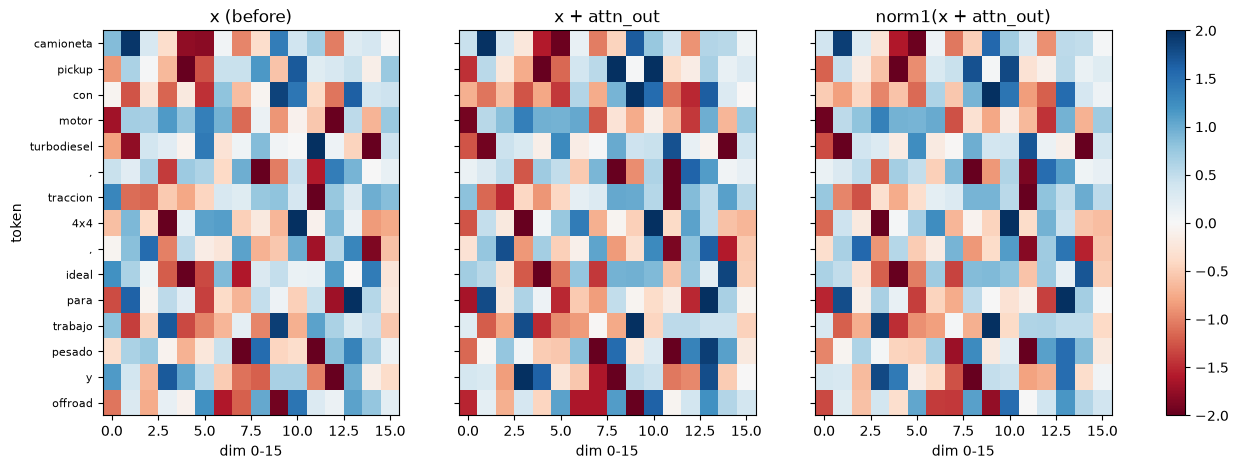

mean per token, before: [-6.7055225e-08  4.4703484e-08 -2.2351742e-08 -3.7252903e-08
 -5.9604645e-08  0.0000000e+00 -1.4901161e-08  1.4901161e-08
  4.4703484e-08 -2.2351742e-08 -3.7252903e-09  1.8626451e-09
 -1.4901161e-08 -2.2351742e-08 -2.6077032e-08]
mean per token, after:  [ 5.9604645e-08  1.1175871e-08 -2.2351742e-08  2.6077032e-08
  1.6763806e-08 -2.2351742e-08  0.0000000e+00 -2.9802322e-08
  0.0000000e+00 -2.2351742e-08 -1.8626451e-08 -3.7252903e-08
  2.2351742e-08 -2.2351742e-08  7.4505806e-09]


In [35]:
import matplotlib.pyplot as plt

tokens = tokenizer.encode(texto).tokens

x_in = x                         # keep the original
residual = x_in + attn_out       # skip connection
x_out = norm1(residual)          # then LayerNorm
# later you can do: x = x_out

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, mat, title in zip(
    axes,
    [x_in, residual, x_out],
    ["x (before)", "x + attn_out", "norm1(x + attn_out)"],
):
    im = ax.imshow(mat.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("dim 0-15")
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
axes[0].set_ylabel("token")
fig.colorbar(im, ax=axes, fraction=0.02)
plt.show()

print("mean per token, before:", x_in.mean(dim=-1).detach().numpy())
print("mean per token, after: ", x_out.mean(dim=-1).detach().numpy())  # ~0

In [36]:
ff_out = ff(x)                                    # 9. feed-forward

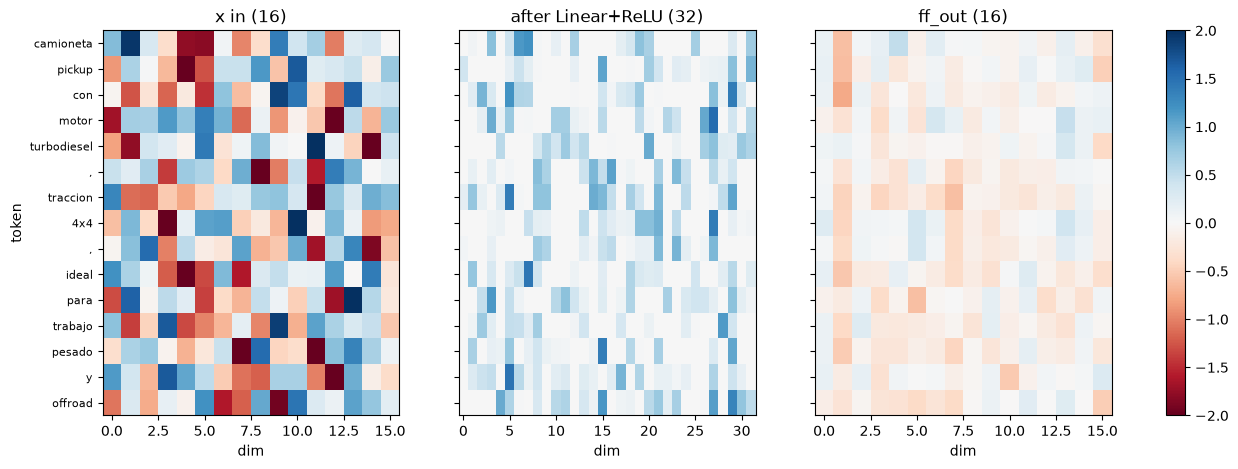

zeros after ReLU: 216 / 480


In [37]:
import matplotlib.pyplot as plt

tokens = tokenizer.encode(texto).tokens

h = ff[0](x).detach()          # Linear 16 → 32
h_relu = ff[1](h).detach()     # ReLU
ff_out = ff[2](h_relu).detach()  # Linear 32 → 16

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, mat, title in zip(
    axes,
    [x, h_relu, ff_out],
    ["x in (16)", "after Linear+ReLU (32)", "ff_out (16)"],
):
    im = ax.imshow(mat.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("dim")
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
axes[0].set_ylabel("token")
fig.colorbar(im, ax=axes, fraction=0.02)
plt.show()

print("zeros after ReLU:", int((h_relu == 0).sum()), "/", h_relu.numel())

In [38]:
x = norm2(x + ff_out)    

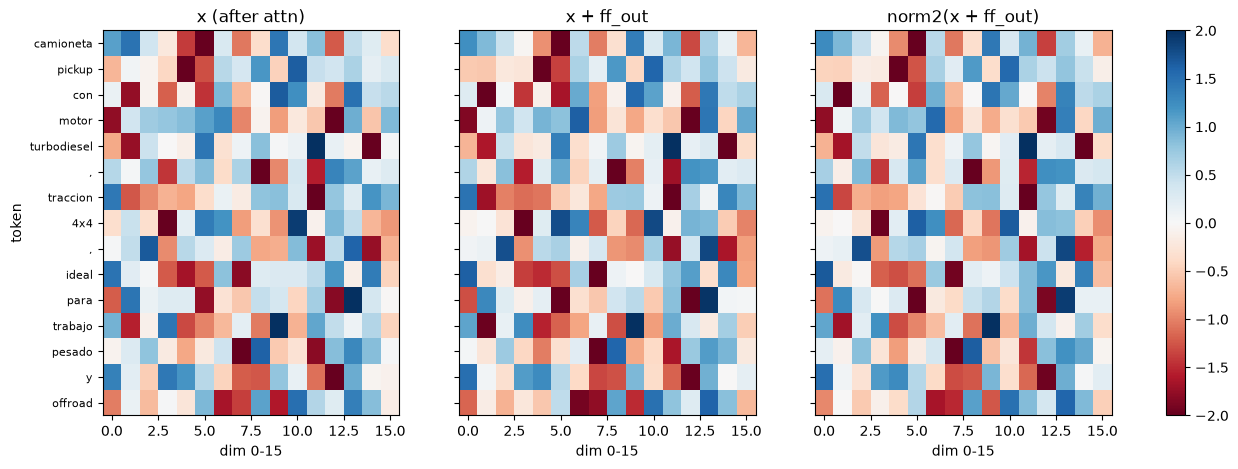

mean per token, before: [ 1.4901161e-08  2.2351742e-08 -3.7252903e-09 -3.7252903e-08
  1.4901161e-08 -1.4901161e-08 -1.1175871e-08  7.4505806e-09
 -7.4505806e-09  0.0000000e+00  3.7252903e-09  1.3038516e-08
  0.0000000e+00  1.4901161e-08 -2.2351742e-08]
mean per token, after:  [-2.2351742e-08  0.0000000e+00  1.1175871e-08  0.0000000e+00
  1.3038516e-08 -2.9802322e-08 -1.4901161e-08 -1.4901161e-08
 -2.7939677e-08  0.0000000e+00  1.3038516e-08  2.1420419e-08
  2.9802322e-08 -7.4505806e-09 -7.4505806e-09]


In [39]:
import matplotlib.pyplot as plt

tokens = tokenizer.encode(texto).tokens

x_ff_in = x                      # after attention + norm1
residual2 = x_ff_in + ff_out
x_ff_out = norm2(residual2)
# later: x = x_ff_out

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, mat, title in zip(
    axes,
    [x_ff_in, residual2, x_ff_out],
    ["x (after attn)", "x + ff_out", "norm2(x + ff_out)"],
):
    im = ax.imshow(mat.detach().numpy(), cmap="RdBu", vmin=-2, vmax=2, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("dim 0-15")
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
axes[0].set_ylabel("token")
fig.colorbar(im, ax=axes, fraction=0.02)
plt.show()

print("mean per token, before:", x_ff_in.mean(dim=-1).detach().numpy())
print("mean per token, after: ", x_ff_out.mean(dim=-1).detach().numpy())  # ~0

In [40]:
import torch
import torch.nn as nn

class TransformerBlock(nn.Module):
    def __init__(self, d, d_ff):
        super().__init__()
        self.Wq = nn.Linear(d, d, bias=False)
        self.Wk = nn.Linear(d, d, bias=False)
        self.Wv = nn.Linear(d, d, bias=False)
        self.norm1 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))
        self.norm2 = nn.LayerNorm(d)

    def forward(self, x):
        Q, K, V = self.Wq(x), self.Wk(x), self.Wv(x)
        scores = Q @ K.transpose(-2, -1) / (x.shape[-1] ** 0.5)
        weights = torch.softmax(scores, dim=-1)
        x = self.norm1(x + weights @ V)
        x = self.norm2(x + self.ff(x))
        return x


class EmbeddingModel(nn.Module):
    def __init__(self, vocab_size, d, d_ff, max_len, n_blocks):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d)
        self.pos_embed = nn.Embedding(max_len, d)
        self.blocks = nn.ModuleList([TransformerBlock(d, d_ff) for _ in range(n_blocks)])

    def forward(self, token_ids):
        positions = torch.arange(len(token_ids))
        x = self.token_embed(token_ids) + self.pos_embed(positions)
        for block in self.blocks:
            x = block(x)
        return x.mean(dim=0)

In [41]:
vocab_size = tokenizer.get_vocab_size()
model = EmbeddingModel(vocab_size=vocab_size, d=16, d_ff=32, max_len=30, n_blocks=2)

In [42]:
# ---- 2. Tokenizador BPE entrenado sobre el corpus ----
textos_entrenamiento = [texto_a + " " + texto_b for texto_a, texto_b, _ in pares]

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(special_tokens=["[UNK]"], vocab_size=500, min_frequency=2)
tokenizer.train_from_iterator(textos_entrenamiento, trainer)

# ---- 3. Modelo ----
class TransformerBlock(nn.Module):
    def __init__(self, d, d_ff):
        super().__init__()
        self.Wq = nn.Linear(d, d, bias=False)
        self.Wk = nn.Linear(d, d, bias=False)
        self.Wv = nn.Linear(d, d, bias=False)
        self.norm1 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))
        self.norm2 = nn.LayerNorm(d)

    def forward(self, x):
        Q, K, V = self.Wq(x), self.Wk(x), self.Wv(x)
        scores = Q @ K.transpose(-2, -1) / (x.shape[-1] ** 0.5)
        weights = torch.softmax(scores, dim=-1)
        x = self.norm1(x + weights @ V)
        x = self.norm2(x + self.ff(x))
        return x

class EmbeddingModel(nn.Module):
    def __init__(self, vocab_size, d, d_ff, max_len, n_blocks):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d)
        self.pos_embed = nn.Embedding(max_len, d)
        self.blocks = nn.ModuleList([TransformerBlock(d, d_ff) for _ in range(n_blocks)])

    def forward(self, token_ids):
        positions = torch.arange(len(token_ids))
        x = self.token_embed(token_ids) + self.pos_embed(positions)
        for block in self.blocks:
            x = block(x)
        return x.mean(dim=0)

def texto_a_ids(texto, tokenizer, max_len):
    ids = tokenizer.encode(texto).ids[:max_len]   # <-- CAMBIO: trunca por seguridad
    return torch.tensor(ids)

def contrastive_loss(vec_a, vec_b, label, margin=0.3):
    cos_sim = nn.functional.cosine_similarity(vec_a.unsqueeze(0), vec_b.unsqueeze(0))
    if label == 1:
        return 1 - cos_sim
    else:
        return torch.clamp(cos_sim - margin, min=0)

# ---- 4. Instanciar y entrenar ----
MAX_LEN = 64   # <-- CAMBIO: antes 30, subido para que quepan textos con Wayra fragmentado

vocab_size = tokenizer.get_vocab_size()
model = EmbeddingModel(vocab_size=vocab_size, d=16, d_ff=32, max_len=MAX_LEN, n_blocks=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(200):
    total_loss = 0.0
    for texto_a, texto_b, label in pares:
        ids_a = texto_a_ids(texto_a, tokenizer, MAX_LEN)
        ids_b = texto_a_ids(texto_b, tokenizer, MAX_LEN)
        vec_a = model(ids_a)
        vec_b = model(ids_b)
        loss = contrastive_loss(vec_a, vec_b, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 20 == 0:
        print(f"epoch {epoch:4d}  loss {total_loss/len(pares):.4f}")


epoch    0  loss 0.1494
epoch   20  loss 0.0159
epoch   40  loss 0.0020
epoch   60  loss 0.0000
epoch   80  loss 0.0062
epoch  100  loss 0.0000
epoch  120  loss 0.0000
epoch  140  loss 0.0000
epoch  160  loss 0.0001
epoch  180  loss 0.0000


In [43]:
wayrapiquero = "wayrapiquero auto electrico premium para la isla, silencioso y elegante"
wayrasacha = "wayrasacha camioneta a gasolina, resistente y aventurera para la selva"

with torch.no_grad():
    vec_piquero = model(texto_a_ids(wayrapiquero, tokenizer, MAX_LEN))
    vec_sacha = model(texto_a_ids(wayrasacha, tokenizer, MAX_LEN))
    vecs_catalogo = {title: model(texto_a_ids(body, tokenizer, MAX_LEN)) for title, body in catalogo}

def cos(a, b):
    return nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

print("\n=== Wayra Piquero vs catalogo ===")
for title, vec in vecs_catalogo.items():
    print(f"  {title:28} {cos(vec_piquero, vec):.3f}")

print("\n=== Wayra Sacha vs catalogo ===")
for title, vec in vecs_catalogo.items():
    print(f"  {title:28} {cos(vec_sacha, vec):.3f}")


=== Wayra Piquero vs catalogo ===
  Toyota Hilux 2024            -0.789
  Ford Ranger 2024             0.261
  Nissan Leaf 2024             -0.383
  Chevrolet Bolt EV 2024       0.119
  BMW X5 2024                  -0.155
  Mercedes-Benz GLE 2024       0.024
  Jeep Wrangler 2024           -0.056
  Land Rover Defender 2024     0.878

=== Wayra Sacha vs catalogo ===
  Toyota Hilux 2024            -0.134
  Ford Ranger 2024             0.121
  Nissan Leaf 2024             -0.229
  Chevrolet Bolt EV 2024       0.511
  BMW X5 2024                  -0.810
  Mercedes-Benz GLE 2024       0.779
  Jeep Wrangler 2024           -0.346
  Land Rover Defender 2024     0.320


In [44]:
# ---- 1. Documentos a indexar: catalogo real + los productos Wayra ----
documentos = {title: body for title, body in catalogo}
documentos["Wayra Piquero"] = "wayrapiquero auto electrico premium para la isla, silencioso y elegante"
documentos["Wayra Sacha"] = "wayrasacha camioneta a gasolina, resistente y aventurera para la selva"

# ---- 2. Almacenar: generar y guardar UN embedding por documento ----
with torch.no_grad():
    index = {nombre: model(texto_a_ids(texto, tokenizer, MAX_LEN)) for nombre, texto in documentos.items()}


In [45]:
index

{'Toyota Hilux 2024': tensor([ 0.9713, -0.6690, -0.8953, -0.1546,  0.0499, -0.2163, -0.4408,  1.1082,
          0.0956, -0.0532,  0.0323,  0.3086,  1.3123, -0.2856,  0.3779, -1.3405]),
 'Ford Ranger 2024': tensor([ 0.4678,  0.4489, -0.6097, -0.3259,  0.5294,  0.1921, -0.0143, -1.4151,
          0.4615,  0.0085, -1.1873,  0.3011,  0.8682,  0.4979, -0.0739, -0.4696]),
 'Nissan Leaf 2024': tensor([-0.1831, -0.5243,  0.3845,  0.0165, -0.1842, -0.1698,  0.3298,  1.2123,
         -0.4782, -0.0315,  1.2666, -0.2435, -0.5907, -0.4934, -0.1136,  0.1118]),
 'Chevrolet Bolt EV 2024': tensor([ 0.3235, -0.2187,  0.1261,  0.9007,  0.7938, -0.1994, -1.1028, -0.0456,
         -0.3048, -0.5482, -0.5517, -0.0569,  0.3297,  0.5220, -0.2324,  0.1418]),
 'BMW X5 2024': tensor([-0.5298,  0.3279,  0.2602,  0.4446,  0.0391, -0.5947,  1.1462, -0.0720,
         -0.0046,  0.6134, -0.6164,  0.5309, -0.1397,  0.4141, -0.9303, -1.0552]),
 'Mercedes-Benz GLE 2024': tensor([ 0.8583, -0.5287, -1.0123, -0.8672,  0.0035

In [46]:
def cos(a, b):
    return nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

def buscar(query, index, model, tokenizer, max_len, topk=3):
    with torch.no_grad():
        vec_query = model(texto_a_ids(query, tokenizer, max_len))
    resultados = [(nombre, cos(vec_query, vec)) for nombre, vec in index.items()]
    return sorted(resultados, key=lambda x: -x[1])[:topk]

In [47]:
resultados = buscar("auto electrico", index, model, tokenizer, MAX_LEN)
for nombre, score in resultados:
    print(f"{nombre:28} {score:.3f}")

Wayra Sacha                  0.852
Mercedes-Benz GLE 2024       0.738
Land Rover Defender 2024     0.411


In [48]:
documentos

{'Toyota Hilux 2024': 'camioneta pickup con motor turbodiesel, traccion 4x4, ideal para trabajo pesado y offroad',
 'Ford Ranger 2024': 'pickup mediana con motor turbo y chasis reforzado, disenada para terrenos dificiles',
 'Nissan Leaf 2024': 'hatchback 100% electrico, silencioso y eficiente, pensado para uso urbano diario',
 'Chevrolet Bolt EV 2024': 'auto electrico compacto, carga rapida, bajo costo de mantenimiento, ideal para la ciudad',
 'BMW X5 2024': 'suv premium con interior de cuero, tecnologia avanzada y motor de alto rendimiento',
 'Mercedes-Benz GLE 2024': 'suv de lujo con suspension adaptativa y acabados premium',
 'Jeep Wrangler 2024': 'todoterreno 4x4 con carroceria removible, disenado para exploracion extrema en montana y rios',
 'Land Rover Defender 2024': 'todoterreno robusto con vadeo profundo, construido para climas humedos y terrenos extremos',
 'Wayra Piquero': 'wayrapiquero auto electrico premium para la isla, silencioso y elegante',
 'Wayra Sacha': 'wayrasacha 

In [49]:
with torch.no_grad():
    vec_leaf = model(texto_a_ids(documentos["Nissan Leaf 2024"], tokenizer, MAX_LEN))
    vec_ranger = model(texto_a_ids(documentos["Ford Ranger 2024"], tokenizer, MAX_LEN))
    vec_query = model(texto_a_ids("auto electrico", tokenizer, MAX_LEN))

print("query vs Leaf:  ", cos(vec_query, vec_leaf))
print("query vs Ranger:", cos(vec_query, vec_ranger))

query vs Leaf:   -0.038711920380592346
query vs Ranger: -0.045342184603214264
